# V3 empirical study — 1.5-year monthly calibration

**This notebook is the computational source of truth.** The PDF in this folder is written from the same `payload` dict, so every table number matches.

| Item | Setting |
|------|---------|
| Models | GBM, GARCH, Heston, Merton, GARCH–Merton, Heston–Merton |
| Companies | SPY, AAPL, MSFT |
| Regimes | Crisis 2008-08-01→2009-07-31 · Normal 2014-01-01→2014-12-31 · Late-cycle 2018-10-01→2019-09-30 · COVID 2019-09-01→2020-08-31 |
| Calibration | **1.5-year** lookback, **monthly** recalibration |
| Primary metric | Percentage RMSE |
| Secondary | MAE, Bias $ (model − market), Bias%, Early-exercise fraction |
| Paths | LSM American calls, `n_paths=2000`, `seed=42` |
| Code | V3 notebooks + `option_filters.py` + Euler-corrected Heston step |

In every table the **BEST** model is the lowest RMSE%. That row is **bold and green**.


## 0. Methodology and conditions

### No look-ahead
At monthly update t, parameters use only returns and listed quotes with `trading_date ≤ t`. LSM prices a Monday contract with the latest calibration row dated on or before that Monday. Option quotes are as-of the grid timestamp (same session, else the prior session).

### Shared sample (no model-specific data selection)
For each company × regime the Monday nearest-ATM listed-call sample is drawn **once** and passed to all six models. Filters, testing dates, simulation settings, and the market benchmark are therefore identical.

### Filters (applied in this order)
1. Calls only; finite S, K, C.
2. No-arbitrage: C ≥ max(0, S−K).
3. Maturity: 7 ≤ DTE ≤ 60.
4. Moneyness: |S/K − 1| ≤ 10%.
5. Liquidity: premium ≥ 0.05; valid bid–ask and relative spread ≤ 50% when those columns exist; volume ≥ 1 when present.

### Metrics
- Primary: RMSE%.
- Secondary: MAE (dollars), Bias $ = mean(model − market), **Bias% = 100 × mean((model − market)/market)**, early-exercise fraction.
- Ranking uses RMSE% only. The dollar bias column is kept; Bias% is the scale-free companion.

### Model-correctness adjustments
- Heston / Heston–Merton: option-implied Fourier NLS for (κ, θ, ξ, ρ, v0). Not Method A.
- Euler: stock return over [t, t+Δt] uses **current** v_t; then update v_{t+Δt}.
- LSM never averages paths before stopping.

### Data limits
Equity adj-close starts **2003-12-01**. Listed-option panels start **2008-01**. Estimators use all available history when the requested lookback is longer than the file.

### Re-run
Set `RECOMPUTE = True` in the next cell and Run All. Default loads `payload.json` if the 12×6 cells are already complete, then rewrites the PDF from that payload.


In [1]:
import sys
from pathlib import Path
from IPython.display import display, HTML, Markdown, Image
ROOT = Path.cwd()
for cand in [ROOT, *ROOT.parents]:
    scripts = cand / 'V3-Models_result' / 'scripts'
    if scripts.exists():
        sys.path.insert(0, str(scripts))
        break
import run_v3_1p5y_monthly_empirical_study as study
RECOMPUTE = False  # True to re-run all 72 calibrations + LSM
payload = study.run_or_load(recompute=RECOMPUTE)
print('cells', len(payload['cells']), 'failures', payload['meta']['failures'])
pdf_path = study.write_pdf(payload)
print('PDF', pdf_path)

## 1. Shared evaluation sample


In [1]:
from IPython.display import HTML, display
rows = ['<h4>n contracts (identical across models)</h4>']
display(HTML(''.join(study._html_table(payload['tables'][k]) if False else '')))
meta = payload['shared_contracts']
import pandas as pd
df = pd.DataFrame([{ 'regime': r, **meta[r]['n'], 'start': meta[r]['period_start'], 'end': meta[r]['period_end']} for r in study.REGIME_ORDER])
display(df)

Regime,Window,SPY,AAPL,MSFT
2008-2009 Crisis,2008-08-01 → 2009-07-31,50,50,50
2013-2014 Normal,2014-01-01 → 2014-12-31,50,50,50
2018-2019 Late-cycle,2018-10-01 → 2019-09-30,50,51,50
2019-2020 COVID,2019-09-01 → 2020-08-31,50,50,50


## 2.1 Detailed tables — `SPY`


### Table SPY-1. SPY · 2008-2009 · Crisis

2008-08-01 → 2009-07-31 · n = 50 contracts · **BEST = Heston–Merton** (lowest RMSE%).


In [1]:
display(HTML(study._html_table(payload['tables']['SPY|2008-2009'])))

Model,RMSE%,MAE,Bias $,Bias%,Early-ex. frac.,Mark
GBM,58.45,1.4530,+0.3503,+23.87,26.3%,6
GARCH,55.06,1.6866,+1.6498,+44.69,27.9%,4
Heston,33.94,1.1172,+0.6042,+21.77,29.1%,2
Merton,53.28,1.3630,+0.2076,+19.26,24.2%,3
GARCH–Merton,58.05,1.8574,+1.8187,+48.43,25.2%,5
Heston–Merton,33.19,1.0903,+0.6216,+21.38,25.0%,1


### Table SPY-2. SPY · 2013-2014 · Normal

2014-01-01 → 2014-12-31 · n = 50 contracts · **BEST = GARCH** (lowest RMSE%).


In [1]:
display(HTML(study._html_table(payload['tables']['SPY|2013-2014'])))

Model,RMSE%,MAE,Bias $,Bias%,Early-ex. frac.,Mark
GBM,39.54,0.7003,+0.5086,+26.46,29.2%,2
GARCH,39.38,0.7038,+0.5049,+26.25,27.7%,1
Heston,53.15,1.0265,+0.9581,+42.98,30.6%,5
Merton,39.94,0.7185,+0.4968,+26.21,26.6%,3
GARCH–Merton,44.27,0.8195,+0.6709,+32.98,28.0%,4
Heston–Merton,68.38,1.3109,+1.2509,+55.17,29.0%,6


### Table SPY-3. SPY · 2018-2019 · Late-cycle

2018-10-01 → 2019-09-30 · n = 50 contracts · **BEST = Merton** (lowest RMSE%).


In [1]:
display(HTML(study._html_table(payload['tables']['SPY|2018-2019'])))

Model,RMSE%,MAE,Bias $,Bias%,Early-ex. frac.,Mark
GBM,51.52,1.7068,+1.2167,+34.33,24.7%,2
GARCH,69.64,2.1225,+1.7298,+45.00,30.2%,3
Heston,74.11,2.3692,+2.1369,+55.34,25.0%,4
Merton,49.57,1.6637,+1.1397,+32.37,22.3%,1
GARCH–Merton,76.63,2.4045,+2.1179,+54.42,28.4%,5
Heston–Merton,86.87,2.8636,+2.6435,+66.91,21.5%,6


### Table SPY-4. SPY · 2019-2020 · COVID

2019-09-01 → 2020-08-31 · n = 50 contracts · **BEST = GARCH** (lowest RMSE%).


In [1]:
display(HTML(study._html_table(payload['tables']['SPY|2019-2020'])))

Model,RMSE%,MAE,Bias $,Bias%,Early-ex. frac.,Mark
GBM,66.95,3.6931,+1.7288,+45.87,26.9%,5
GARCH,59.32,3.0718,+2.3450,+37.04,38.1%,1
Heston,66.39,3.8056,+2.6632,+50.76,30.2%,4
Merton,62.95,3.5023,+1.4543,+41.75,21.6%,2
GARCH–Merton,63.13,3.3311,+2.5402,+43.61,37.0%,3
Heston–Merton,67.60,3.5696,+2.4566,+48.77,18.6%,6


## 2.2 Detailed tables — `AAPL`


### Table AAPL-1. AAPL · 2008-2009 · Crisis

2008-08-01 → 2009-07-31 · n = 50 contracts · **BEST = Heston** (lowest RMSE%).


In [1]:
display(HTML(study._html_table(payload['tables']['AAPL|2008-2009'])))

Model,RMSE%,MAE,Bias $,Bias%,Early-ex. frac.,Mark
GBM,61.13,2.5357,+1.5246,+33.58,24.8%,5
GARCH,53.39,2.8266,+2.6794,+43.19,23.7%,3
Heston,32.43,1.6546,+1.1227,+21.96,27.1%,1
Merton,57.68,2.4293,+1.3903,+30.98,23.2%,4
GARCH–Merton,61.41,3.4149,+3.3207,+52.81,22.9%,6
Heston–Merton,34.23,1.6730,+1.1881,+23.23,21.9%,2


### Table AAPL-2. AAPL · 2013-2014 · Normal

2014-01-01 → 2014-12-31 · n = 50 contracts · **BEST = Heston–Merton** (lowest RMSE%).


In [1]:
display(HTML(study._html_table(payload['tables']['AAPL|2013-2014'])))

Model,RMSE%,MAE,Bias $,Bias%,Early-ex. frac.,Mark
GBM,52.06,3.6666,+3.6326,+40.10,28.6%,5
GARCH,47.66,3.2942,+3.1762,+31.21,27.1%,4
Heston,38.62,2.5601,+2.5591,+30.71,26.3%,2
Merton,47.54,3.3845,+3.3397,+35.82,23.4%,3
GARCH–Merton,68.15,5.1518,+5.1479,+55.83,22.5%,6
Heston–Merton,32.93,2.0632,+2.0407,+22.48,21.0%,1


### Table AAPL-3. AAPL · 2018-2019 · Late-cycle

2018-10-01 → 2019-09-30 · n = 51 contracts · **BEST = Merton** (lowest RMSE%).


In [1]:
display(HTML(study._html_table(payload['tables']['AAPL|2018-2019'])))

Model,RMSE%,MAE,Bias $,Bias%,Early-ex. frac.,Mark
GBM,34.01,1.7715,+1.1125,+20.36,26.3%,2
GARCH,48.92,2.0791,+1.6369,+30.32,26.3%,5
Heston,45.30,2.3807,+2.3093,+38.77,28.5%,4
Merton,32.33,1.6676,+1.0112,+18.85,23.8%,1
GARCH–Merton,60.90,2.7654,+2.5372,+44.94,24.6%,6
Heston–Merton,44.15,2.2146,+2.0747,+35.15,24.1%,3


### Table AAPL-4. AAPL · 2019-2020 · COVID

2019-09-01 → 2020-08-31 · n = 50 contracts · **BEST = Heston–Merton** (lowest RMSE%).


In [1]:
display(HTML(study._html_table(payload['tables']['AAPL|2019-2020'])))

Model,RMSE%,MAE,Bias $,Bias%,Early-ex. frac.,Mark
GBM,47.86,4.2247,+2.6177,+32.64,27.8%,4
GARCH,63.11,5.0239,+4.4985,+44.33,34.0%,5
Heston,42.43,3.7882,+3.0597,+33.78,29.9%,2
Merton,46.09,3.8303,+2.1912,+29.59,23.6%,3
GARCH–Merton,72.22,6.2435,+5.7535,+58.33,27.8%,6
Heston–Merton,41.64,3.5324,+2.5584,+30.70,21.5%,1


## 2.3 Detailed tables — `MSFT`


### Table MSFT-1. MSFT · 2008-2009 · Crisis

2008-08-01 → 2009-07-31 · n = 50 contracts · **BEST = Heston** (lowest RMSE%).


In [1]:
display(HTML(study._html_table(payload['tables']['MSFT|2008-2009'])))

Model,RMSE%,MAE,Bias $,Bias%,Early-ex. frac.,Mark
GBM,46.75,0.3814,+0.1096,+20.10,27.0%,4
GARCH,72.50,0.5968,+0.5538,+55.64,37.3%,5
Heston,28.27,0.2618,+0.1014,+13.94,29.9%,1
Merton,44.85,0.3804,+0.0927,+18.17,23.1%,3
GARCH–Merton,85.11,0.7656,+0.7296,+70.93,32.0%,6
Heston–Merton,28.33,0.2652,+0.1155,+15.14,24.2%,2


### Table MSFT-2. MSFT · 2013-2014 · Normal

2014-01-01 → 2014-12-31 · n = 50 contracts · **BEST = Heston–Merton** (lowest RMSE%).


In [1]:
display(HTML(study._html_table(payload['tables']['MSFT|2013-2014'])))

Model,RMSE%,MAE,Bias $,Bias%,Early-ex. frac.,Mark
GBM,64.39,0.4456,+0.4456,+55.00,27.9%,4
GARCH,94.35,0.6883,+0.6883,+82.46,28.2%,5
Heston,32.71,0.1999,+0.1659,+22.40,27.2%,2
Merton,58.34,0.3957,+0.3880,+48.65,21.5%,3
GARCH–Merton,116.07,0.8814,+0.8814,+104.79,27.3%,6
Heston–Merton,28.90,0.1793,+0.1345,+18.78,15.9%,1


### Table MSFT-3. MSFT · 2018-2019 · Late-cycle

2018-10-01 → 2019-09-30 · n = 50 contracts · **BEST = Heston–Merton** (lowest RMSE%).


In [1]:
display(HTML(study._html_table(payload['tables']['MSFT|2018-2019'])))

Model,RMSE%,MAE,Bias $,Bias%,Early-ex. frac.,Mark
GBM,43.83,1.1281,+0.8619,+29.36,26.1%,4
GARCH,44.65,1.1166,+0.9640,+32.10,26.2%,5
Heston,37.65,0.9636,+0.8374,+26.73,28.7%,2
Merton,42.00,1.0879,+0.8015,+27.38,23.4%,3
GARCH–Merton,54.96,1.4249,+1.3549,+44.02,23.5%,6
Heston–Merton,34.59,0.8448,+0.6921,+21.89,21.0%,1


### Table MSFT-4. MSFT · 2019-2020 · COVID

2019-09-01 → 2020-08-31 · n = 50 contracts · **BEST = Heston–Merton** (lowest RMSE%).


In [1]:
display(HTML(study._html_table(payload['tables']['MSFT|2019-2020'])))

Model,RMSE%,MAE,Bias $,Bias%,Early-ex. frac.,Mark
GBM,47.79,2.1217,+1.1208,+30.05,27.1%,4
GARCH,66.83,2.6466,+2.1894,+39.01,34.7%,5
Heston,41.31,2.1263,+1.5877,+31.36,28.1%,2
Merton,46.87,2.0173,+0.9824,+28.29,22.6%,3
GARCH–Merton,72.53,3.0574,+2.4901,+45.89,34.0%,6
Heston–Merton,35.15,1.7877,+1.1299,+21.12,22.3%,1


## 3. Summary tables


### Table S1 — Overall ranking


In [1]:
display(HTML('overall ranking table is rendered from payload["summary_overall"]'))

Rank,Model,Mean RMSE%,Median RMSE%,# cells best
1,Heston BEST,43.86,39.96,2
2,Heston–Merton,44.66,34.87,6
3,Merton,48.45,47.21,2
4,GBM,51.19,49.69,0
5,GARCH,59.57,57.19,2
6,GARCH–Merton,69.45,65.64,0


## 4. Figures


### Figure 1 — RMSE% by regime (mean of three companies)


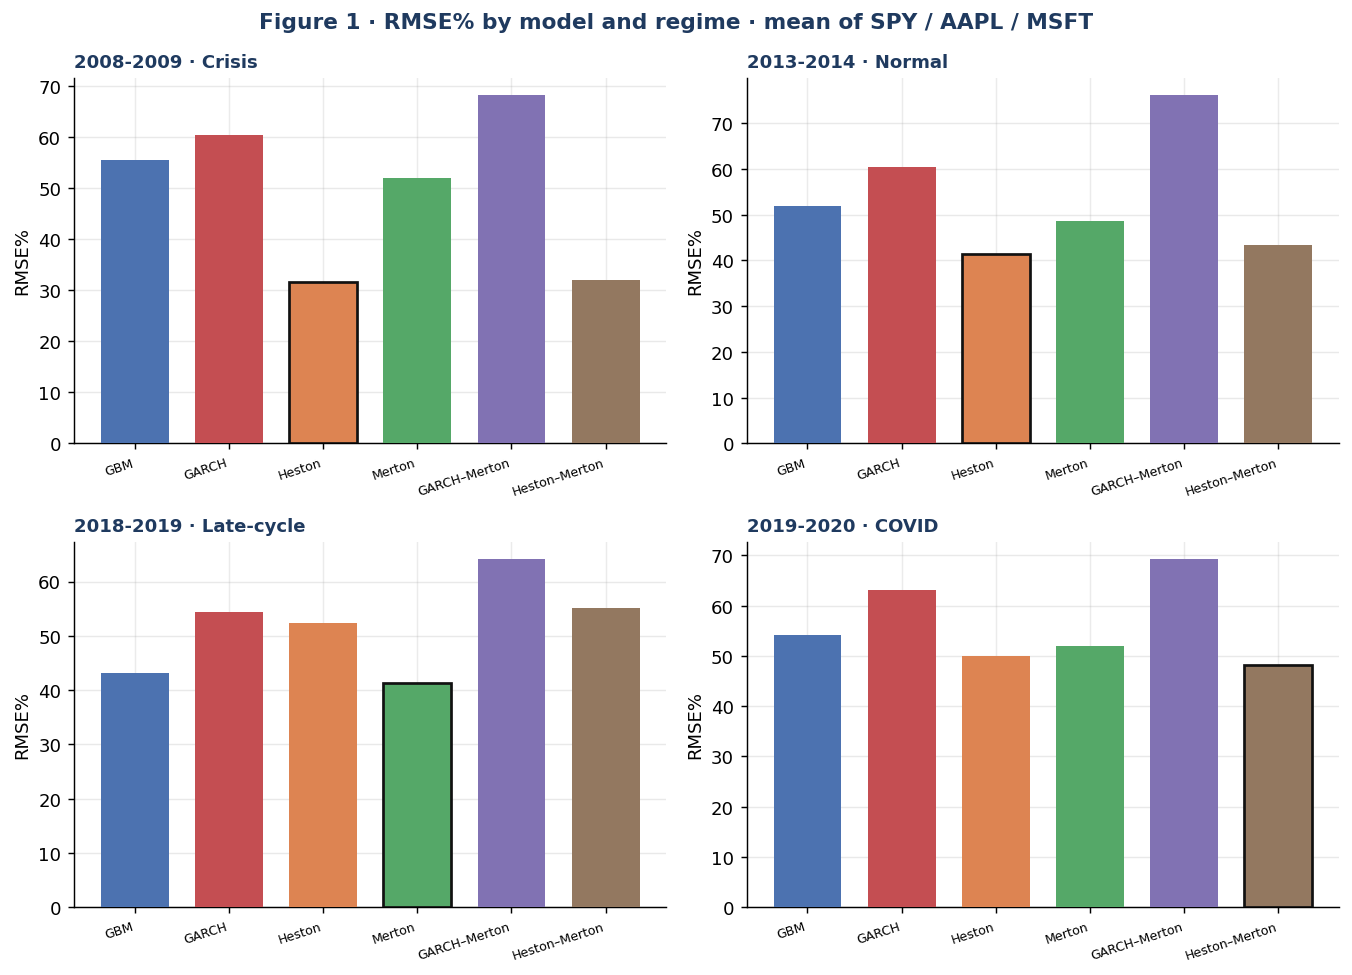

In [1]:
pass  # figure embedded from the same payload used for the PDF

### Figure 2 — RMSE% by company


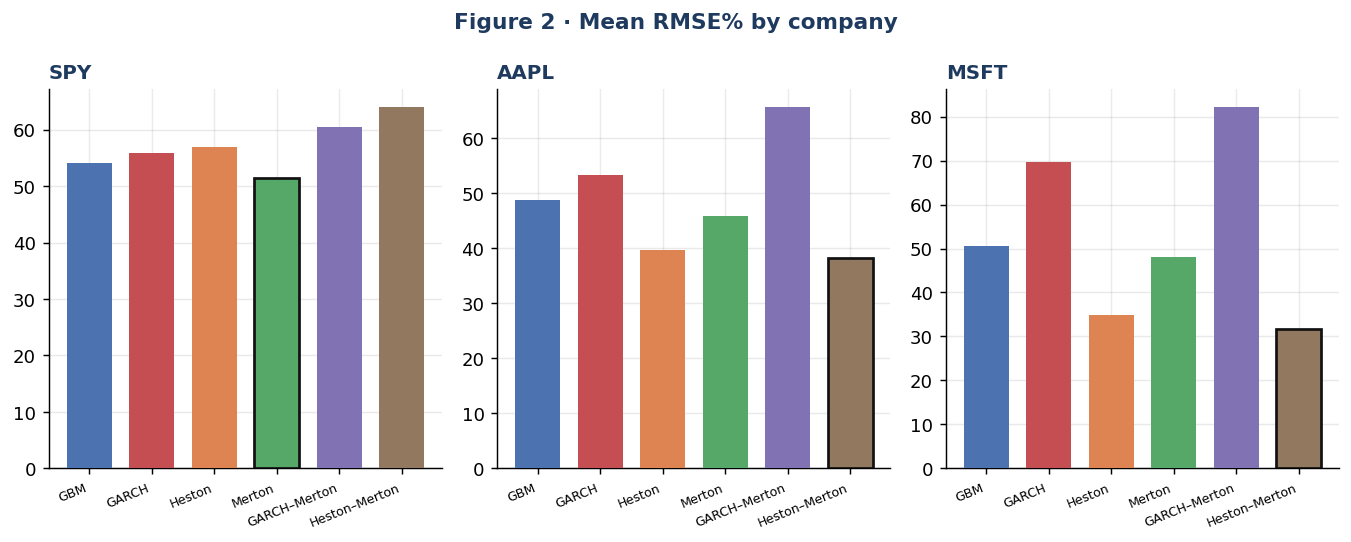

In [1]:
pass

### Figure 3 — Rank heatmap


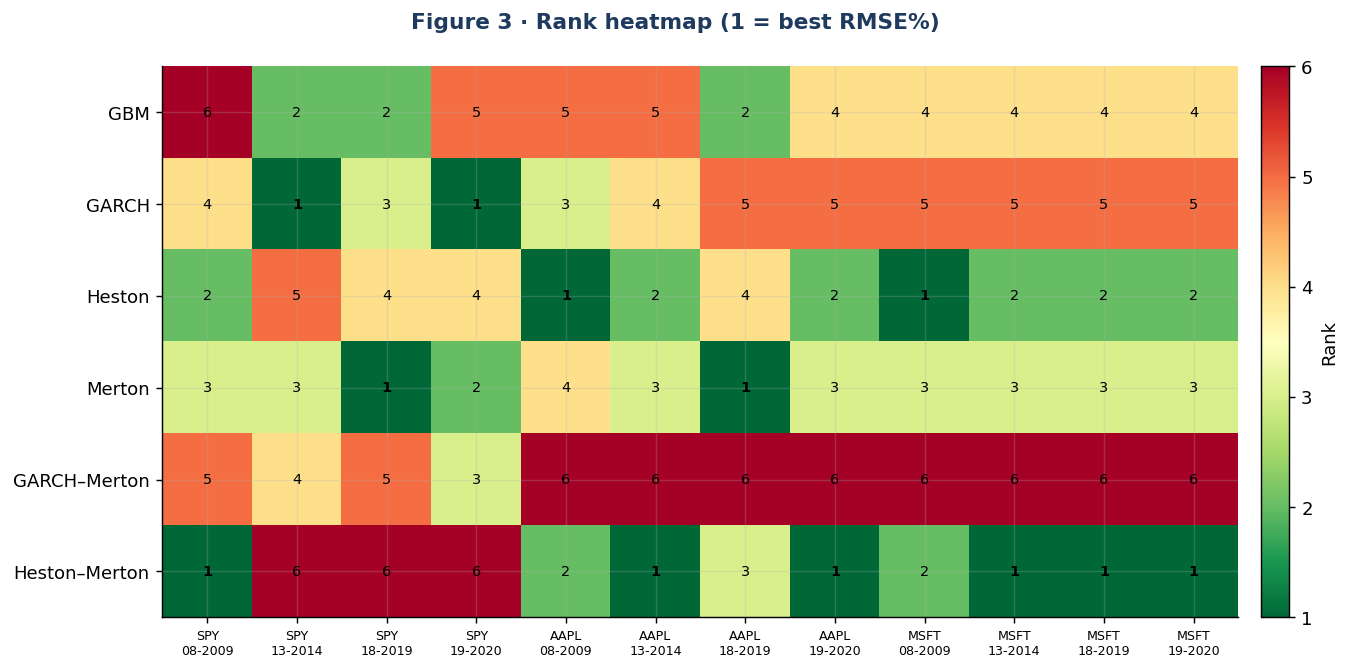

In [1]:
pass

## 5. Final analysis

- On mean percentage RMSE across the 12 company×regime cells, Heston is the best overall model (mean RMSE% = 43.86; 2 of 12 cells).

- Second overall is Heston–Merton (mean RMSE% = 44.66; 6 cells).

- The ranking is not stable. Best-in-cell models across the 12 tables: GARCH, Heston, Heston–Merton, Merton.

- SPY: lowest mean RMSE% is Merton (51.43); wins 1 of 4 regimes.

- AAPL: lowest mean RMSE% is Heston–Merton (38.24); wins 2 of 4 regimes.

- MSFT: lowest mean RMSE% is Heston–Merton (31.74); wins 3 of 4 regimes.

- 2008-2009 (Crisis): best mean RMSE% is Heston (31.55).

- 2013-2014 (Normal): best mean RMSE% is Heston (41.49).

- 2018-2019 (Late-cycle): best mean RMSE% is Merton (41.30).

- 2019-2020 (COVID): best mean RMSE% is Heston–Merton (48.13).

- No-jump models as a group have lower mean RMSE% (51.54) than the three jump models (54.19).

- For the overall winner (Heston), crisis RMSE% is 31.55 vs 41.49 in the 2014 normal year — absolute pricing error is regime-dependent even when the ranking is not.

- These conclusions are conditional on the V3 filters, 1.5-year monthly calibration, Monday ATM sample, LSM with 2,000 paths, and American-call quotes only. They are not a statement about European options or other tenors.


## 6. Reproducibility

```python
RECOMPUTE = True
payload = study.run_or_load(recompute=True)
study.write_pdf(payload)
study.build_notebook(payload)
```

Partial results resume from `V3-Models_result/results/empirical_study_1p5y_monthly/partial/`.
Shared contracts are frozen in `shared_contracts.json` so a resumed run cannot silently change the sample.
